<a href="https://colab.research.google.com/github/wjx2193675108/SD-v1-4-Tea-fine-tuning/blob/main/SD1_4_%E8%8C%B6%E5%8F%B6%E5%AE%A3%E4%BC%A0%E5%9B%BE%E7%94%9F%E6%88%90%E5%BE%AE%E8%B0%83_%E5%AE%89%E5%90%89%E7%99%BD%E8%8C%B6%2B%E9%93%81%E8%A7%82%E9%9F%B3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from transformers import CLIPTokenizer

#定义checkpoint
checkpoint = 'wjx325/AnjiBaicha_stable-diffusion-v1-4'

#加载tokenizer
tokenizer = CLIPTokenizer.from_pretrained(
    checkpoint,
    subfolder='tokenizer',
)

#添加新词
tokenizer.add_tokens('<Tieguanyin>')

tokenizer

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/914 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.06M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/29.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

CLIPTokenizer(name_or_path='wjx325/AnjiBaicha_stable-diffusion-v1-4', vocab_size=49408, model_max_length=77, is_fast=False, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<|startoftext|>', 'eos_token': '<|endoftext|>', 'unk_token': '<|endoftext|>', 'pad_token': '<|endoftext|>'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	49406: AddedToken("<|startoftext|>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	49407: AddedToken("<|endoftext|>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	49408: AddedToken("<Anji_baicha>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=False),
	49409: AddedToken("<Tieguanyin>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=False),
}
)

In [2]:
texts = [
    'Hand-roasted <Tieguanyin>',
    '<Tieguanyin> picked before the rainy season',
    'Premium-grade <Tieguanyin> buds and leaves',
    'Aroma of high-mountain <Tieguanyin>',
    'Organic <Tieguanyin> dried tea leaves',
    '<Tieguanyin> from the spring tea season',
    'Precious <Tieguanyin> tea leaves',
    'Sweet flavor of <Tieguanyin>',
    'Whole buds and leaves of <Tieguanyin>',
    'Emerald green <Tieguanyin> tea leaves',
    'All-natural <Tieguanyin>',
    'Refreshment of cold-brewed <Tieguanyin>',
    'Nuances of aged <Tieguanyin>',
    '<Tieguanyin> with long-lasting fragrance',
    'Mellow mouthfeel of <Tieguanyin>',
    'Delicate aroma of <Tieguanyin>',
    'Close-up of tender <Tieguanyin> buds',
    '<Tieguanyin> nurtured by rain and dew',
]

#图片列表,总共只有4张图片
files = [
    'datas/Tieguanyin/t1.jpg',
    'datas/Tieguanyin/t2.jpg',
    'datas/Tieguanyin/t3.jpg',
    'datas/Tieguanyin/t4.jpg',
]

In [3]:
import torch
import torchvision
import random
import PIL.Image
import numpy as np


#定义数据集
class Dataset(torch.utils.data.Dataset):

    def __init__(self):
        self.flip_transform = torchvision.transforms.RandomHorizontalFlip(
            p=0.5)

    def __len__(self):
        return len(files)

    def __getitem__(self, i):
        data = {}

        #选择选择一段文字,并编码
        data['input_ids'] = tokenizer(
            random.choice(texts),
            padding='max_length',
            truncation=True,
            max_length=77,
            return_tensors='pt',
        )['input_ids'][0]

        #加载图片
        image = PIL.Image.open(files[i])

        #图像增强
        image = PIL.Image.fromarray(np.array(image).astype(np.uint8))
        image = image.resize((512, 512), resample=PIL.Image.BICUBIC)
        image = self.flip_transform(image)
        image = np.array(image).astype(np.uint8)
        image = (image / 127.5 - 1.0).astype(np.float32)

        data['pixel_values'] = torch.from_numpy(image).permute(2, 0, 1)

        return data


dataset = Dataset()

len(dataset), dataset[0]

(4,
 {'input_ids': tensor([49406,  8011,   268,  3394, 49409, 14665,   537,  5579, 49407, 49407,
          49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
          49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
          49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
          49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
          49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
          49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
          49407, 49407, 49407, 49407, 49407, 49407, 49407]),
  'pixel_values': tensor([[[-0.3882, -0.3961, -0.4118,  ...,  0.3412,  0.3412,  0.3412],
           [-0.4667, -0.4510, -0.4275,  ...,  0.3412,  0.3412,  0.3412],
           [-0.4745, -0.4667, -0.4588,  ...,  0.3490,  0.3490,  0.3490],
           ...,
           [ 0.8824,  0.8745,  0.8667,  ...,  0.8824,  0.8824,  0.8745],
           [ 0.8902,  0.8824,  0.8745,

In [4]:
loader = torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=True)

for i, data in enumerate(loader):
    break

len(loader), data

(4,
 {'input_ids': tensor([[49406,  8226, 49409,  3274,  5579, 49407, 49407, 49407, 49407, 49407,
           49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
           49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
           49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
           49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
           49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
           49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
           49407, 49407, 49407, 49407, 49407, 49407, 49407]]),
  'pixel_values': tensor([[[[-0.5216, -0.5216, -0.5137,  ...,  0.1216,  0.1765,  0.2000],
            [-0.5216, -0.5216, -0.5137,  ...,  0.1216,  0.1765,  0.2000],
            [-0.5373, -0.5373, -0.5294,  ...,  0.1137,  0.1686,  0.2000],
            ...,
            [-0.2627, -0.2627, -0.2627,  ..., -0.9059, -0.9059, -0.9059],
            [-0.2549, -0

In [9]:
from transformers import CLIPTextModel
from diffusers import AutoencoderKL, UNet2DConditionModel


def init_models():
    #加载模型
    text_encoder = CLIPTextModel.from_pretrained(checkpoint, subfolder='text_encoder')
    vae = AutoencoderKL.from_pretrained(checkpoint, subfolder='vae')
    unet = UNet2DConditionModel.from_pretrained(checkpoint, subfolder='unet')

    text_encoder.train()
    vae.eval()
    unet.eval()

    #添加新词
    text_encoder.resize_token_embeddings(tokenizer.vocab_size + 1)

    #初始化新词的参数 tea -> <Anji_baicha>
    token_embeds = text_encoder.get_input_embeddings().weight.data
    token_embeds[49408] = token_embeds[3274]

    #冻结参数
    for param in vae.parameters():
        param.requires_grad = False

    for param in unet.parameters():
        param.requires_grad = False

    for name, param in text_encoder.named_parameters():
        #除了这一层,其他全部冻结
        if name != 'text_model.embeddings.token_embedding.weight':
            param.requires_grad = False

    return text_encoder, vae, unet


text_encoder, vae, unet = init_models()

In [10]:
from diffusers import DDPMScheduler

noise_scheduler = DDPMScheduler(beta_start=0.00085,
                 beta_end=0.012,
                 beta_schedule='scaled_linear',
                 num_train_timesteps=1000)

noise_scheduler

DDPMScheduler {
  "_class_name": "DDPMScheduler",
  "_diffusers_version": "0.33.1",
  "beta_end": 0.012,
  "beta_schedule": "scaled_linear",
  "beta_start": 0.00085,
  "clip_sample": true,
  "clip_sample_range": 1.0,
  "dynamic_thresholding_ratio": 0.995,
  "num_train_timesteps": 1000,
  "prediction_type": "epsilon",
  "rescale_betas_zero_snr": false,
  "sample_max_value": 1.0,
  "steps_offset": 0,
  "thresholding": false,
  "timestep_spacing": "leading",
  "trained_betas": null,
  "variance_type": "fixed_small"
}

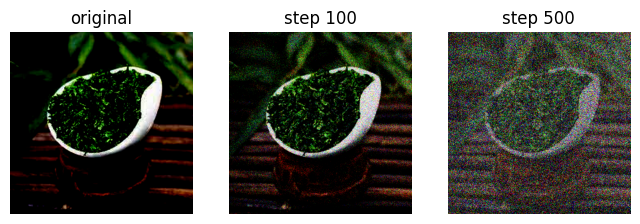

In [11]:
from matplotlib import pyplot as plt
%matplotlib inline

def test_noise_scheduler():

    def show(image, idx, title):
        plt.subplot(1, 3, idx)
        plt.imshow(image.squeeze(dim=0).permute(1, 2, 0))
        plt.axis('off')
        plt.title(title)

    plt.figure(figsize=[8, 3])

    #打印原始图片
    image = data['pixel_values']
    show(image, 1, 'original')

    #随机噪声
    noise = torch.randn(image.shape)

    #混合到100步
    image_noise = noise_scheduler.add_noise(image, noise, torch.LongTensor([100]))
    show(image_noise, 2, 'step 100')

    #混合到500步
    image_noise = noise_scheduler.add_noise(image, noise, torch.LongTensor([500]))
    show(image_noise, 3, 'step 500')

    plt.show()


test_noise_scheduler()

In [12]:
def forward(data):
    device = data['pixel_values'].device

    #使用vae压缩原图像
    #[1, 3, 512, 512] -> [1, 4, 64, 64]
    latents = vae.encode(data['pixel_values']).latent_dist.sample().detach()
    latents = latents * 0.18215

    #随机b张噪声图
    #[1, 4, 64, 64]
    noise = torch.randn(latents.shape).to(device)

    #随机采样0-1000之间的b个数字,为每张图片随机一个步数
    #[1]
    timesteps = torch.randint(0, 1000, (1, ), device=device).long()

    #把噪声添加到压缩图中,维度不变
    noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)

    #编码文字
    #[1, 77, 768]
    encoder_hidden_states = text_encoder(data['input_ids'])[0]

    #根据文字信息,从混合图中把噪声图给抽取出来
    #[1, 4, 64, 64]
    noise_pred = unet(noisy_latents, timesteps, encoder_hidden_states).sample

    #求mse loss即可
    #[1, 4, 64, 64]
    loss = torch.nn.functional.mse_loss(noise_pred, noise, reduction='none')
    #[1, 4, 64, 64] -> [1]
    loss = loss.mean(dim=[1, 2, 3])

    return loss


forward(data)

IndexError: index out of range in self

In [ ]:
from diffusers import PNDMScheduler, StableDiffusionPipeline
from diffusers.pipelines.stable_diffusion import StableDiffusionSafetyChecker
from transformers import CLIPFeatureExtractor


def save():
    #保存模型
    pipeline = StableDiffusionPipeline(
        text_encoder=text_encoder,
        vae=vae,
        unet=unet,
        tokenizer=tokenizer,
        scheduler=PNDMScheduler(beta_start=0.00085,
                    beta_end=0.012,
                    beta_schedule='scaled_linear',
                    skip_prk_steps=True),
        safety_checker=StableDiffusionSafetyChecker.from_pretrained('CompVis/stable-diffusion-safety-checker'),
        feature_extractor=CLIPFeatureExtractor.from_pretrained('openai/clip-vit-base-patch32'),
    )
    pipeline.save_pretrained('models/Tieguanyin')
    #保存新词的映射
    learned_embeds = text_encoder.get_input_embeddings().weight[49408].detach(
    ).cpu()
    torch.save({49408: learned_embeds}, 'models/Tieguanyin/learned_embeds.bin')


save()

/usr/local/lib/python3.11/dist-packages/transformers/models/clip/feature_extraction_clip.py:28: FutureWarning: The class CLIPFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use CLIPImageProcessor instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/diffusers/pipelines/stable_diffusion/pipeline_stable_diffusion.py:221: FutureWarning: The configuration file of this scheduler: PNDMScheduler {
  "_class_name": "PNDMScheduler",
  "_diffusers_version": "0.32.2",
  "beta_end": 0.012,
  "beta_schedule": "scaled_linear",
  "beta_start": 0.00085,
  "num_train_timesteps": 1000,
  "prediction_type": "epsilon",
  "set_alpha_to_one": false,
  "skip_prk_steps": true,
  "steps_offset": 0,
  "timestep_spacing": "leading",
  "trained_betas": null
}
 is outdated. `steps_offset` should be set to 1 instead of 0. Please make sure to update the config accordingly as leaving `steps_offset` might led to incorrect results in future versions. If you have downl

In [ ]:
def test(prompt):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'


    #加载
    pipe = StableDiffusionPipeline.from_pretrained('models/Tieguanyin',torch_dtype=torch.float32)

    pipe = pipe.to(device)

    #运算
    images = pipe([prompt] * 2, num_inference_steps=30,
                  guidance_scale=7.5).images

    #画图
    def show(image, idx):
        plt.subplot(1, 4, idx)
        plt.imshow(image)
        plt.axis('off')

    plt.figure(figsize=[8, 3])
    for i in range(len(images)):
        show(images[i], i + 1)
    plt.show()


test('Hand-roasted <Tieguanyin>')

NameError: name 'torch' is not defined

In [ ]:
def train():
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    global text_encoder
    global vae
    global unet

    text_encoder = text_encoder.to(device)
    vae = vae.to(device)
    unet = unet.to(device)

    optimizer = torch.optim.AdamW(
        text_encoder.get_input_embeddings().parameters(),
        lr=2e-3,
    )

    loss_mean = []
    for epoch in range(100):
        for i, data in enumerate(loader):
            data['pixel_values'] = data['pixel_values'].to(device)
            data['input_ids'] = data['input_ids'].to(device)

            loss = forward(data)
            loss.backward()

            #把除了新词以外,其他词的梯度置为0
            grads = text_encoder.get_input_embeddings().weight.grad
            for j in range(grads.shape[0]):
                if j != 49408:
                    grads[j, :] = 0

            optimizer.step()
            optimizer.zero_grad()

            loss_mean.append(loss.item())

             # 释放内存
            del pixel_values, input_ids, latents, noise, noisy_latents, encoder_hidden_states, noise_pred, loss
            torch.cuda.empty_cache()

        if epoch % 20 == 0:
            print(epoch, np.mean(loss_mean))
            loss_mean = []

    save()


train()

0 0.18479729909449816
30 0.15242565468652175
60 0.15335307230319206
90 0.17186710573150776
120 0.17361760208150373
150 0.15202098303319264
180 0.15031876782498632


NameError: name 'model' is not defined

In [ ]:
test('Hand-roasted <Tieguanyin>')

NameError: name 'test' is not defined

In [ ]:
from google.colab import userdata
from huggingface_hub import create_repo, login, HfApi
from diffusers import DiffusionPipeline
import torch

from huggingface_hub import HfApi

# 1. 获取 Hugging Face Token
TeaImageGenerate_TOKEN = userdata.get('TeaImageGenerate_TOKEN')  # 替换为你的 Token 变量名

# 2. 创建仓库（若不存在）
repo_name = "wjx325/Tea_Image_Anjibaicha+Tieguanyin"  # 替换为目标仓库名
create_repo(repo_name, token=TeaImageGenerate_TOKEN, exist_ok=True)

# 3. 直接上传已保存的完整模型文件夹（无需加载）
api = HfApi()
api.upload_folder(
    folder_path="models/Tieguanyin",
    repo_id="wjx325/Tea_Image_Anjibaicha+Tieguanyin",
    repo_type="model",
    token=TeaImageGenerate_TOKEN
)


model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

Upload 5 LFS files:   0%|          | 0/5 [00:00<?, ?it/s]

learned_embeds.bin:   0%|          | 0.00/4.29k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/492M [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/wjx325/cat_toy_stable_diffusion/commit/f0f973bc9fcd37e5bb966a285a0d69c362a8b981', commit_message='Upload folder using huggingface_hub', commit_description='', oid='f0f973bc9fcd37e5bb966a285a0d69c362a8b981', pr_url=None, repo_url=RepoUrl('https://huggingface.co/wjx325/cat_toy_stable_diffusion', endpoint='https://huggingface.co', repo_type='model', repo_id='wjx325/cat_toy_stable_diffusion'), pr_revision=None, pr_num=None)